# Group 1 - Health Insurance Predictions

### Eduardo Debes, Nicolas Guadamillas, Benedetta Pagliardi, Marco Siñaniz, Max Vanderlinden

For this project, we have found a dataset with health insurance clients' personal data and their prices. The main objective is to use these features to predict future clients prices.

- **Age:** Age of the client
- **Sex:** Male or Female
- **BMI:** Body Mass Index (proportionate weight measure regardless of height or strength)
- **Children:** Number of children the client has
- **Smoker:** Boolean column, true if the client smokes false otherwise
- **Region:** Region where the client lives (northeast, northwest, southeast, southwest)
- **Charges (target):** Health insurance cost for that client

## Imports and Data Upload



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
# Raw data uploading

raw_df = pd.read_csv("insurance.csv")
raw_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Explorartion

In [ ]:
nrows, ncols = raw_df.shape
nrows, ncols

(1338, 7)

In [ ]:
raw_df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [ ]:
TARGET = "charges"

obj_cols = raw_df.select_dtypes(include=["object", "category"]).columns.to_list() # Store object columns into separate variable
num_cols = raw_df.select_dtypes(include=["int64", "float64"]).columns.to_list() # Store numeric columns into separate value

display(obj_cols)
display(num_cols)
display(TARGET)

['sex', 'smoker', 'region']

['age', 'bmi', 'children', 'charges']

'charges'

### NaN Analysis

We checked if the data has any NaN values and, if so, understand them in the business context. For this dataset, all records are complete which makes sense given the importance of data accuracy in the health industry.

In [ ]:
# NaN count

raw_df.isna().sum().sort_values(ascending=False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

We also check inside the values of the object columns to ensure there is no "missing" or unnatural data stored as strings.

In [ ]:
for cols in obj_cols:
    display(raw_df[cols].unique())

array(['female', 'male'], dtype=object)

array(['yes', 'no'], dtype=object)

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

### Features distribution

Age shows a fairly uniform distribution with slight concentration on the middle ages. There are no outliers seen in the boxplot, therefore, we can keep this feature as is with no transformations.

BMI shows a fairly normal distribution, however there are slight outliers above the maximum that can be observed in the boxplot. Those outliers might affect the prediction, however given their small magnitude no transformation has been done as of now.

Children is a discrete variable, so the distribution and boxplot make sense to show as they are. We will skip this feature and leave as is.

Charges shows a significant right skewness and heavy tailness with multiple outliers in the upper bound. This makes sense given the small amount of clients that have features that highly impact costs of health insurance such as smoking, old age, high BMI, or combinations of all. Given these factors along with charges being our target feature, we will perform a log transformation as to make the data more symmetric. We don't remove the outliers since these are real cases for a small amount of people (we still wish to capture this cost increase for these types of people).

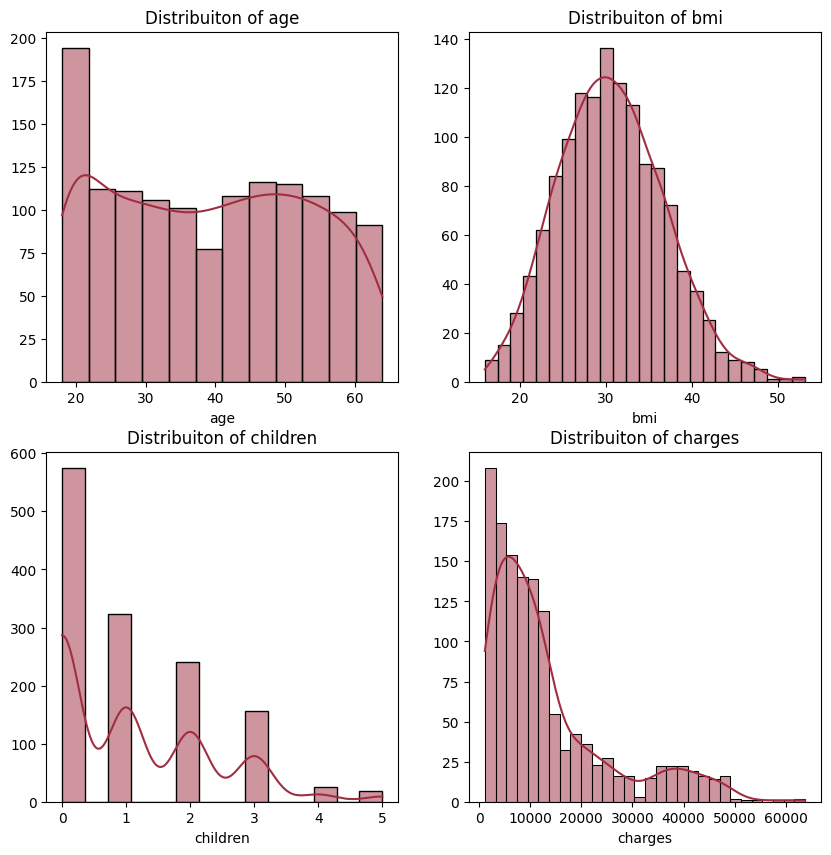

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, cols in enumerate(num_cols):
    sns.histplot(raw_df[cols], kde=True, ax=axes[i], color="#a12d41")
    axes[i].set_title(f"Distribuiton of {cols}")
    axes[i].set_ylabel("")

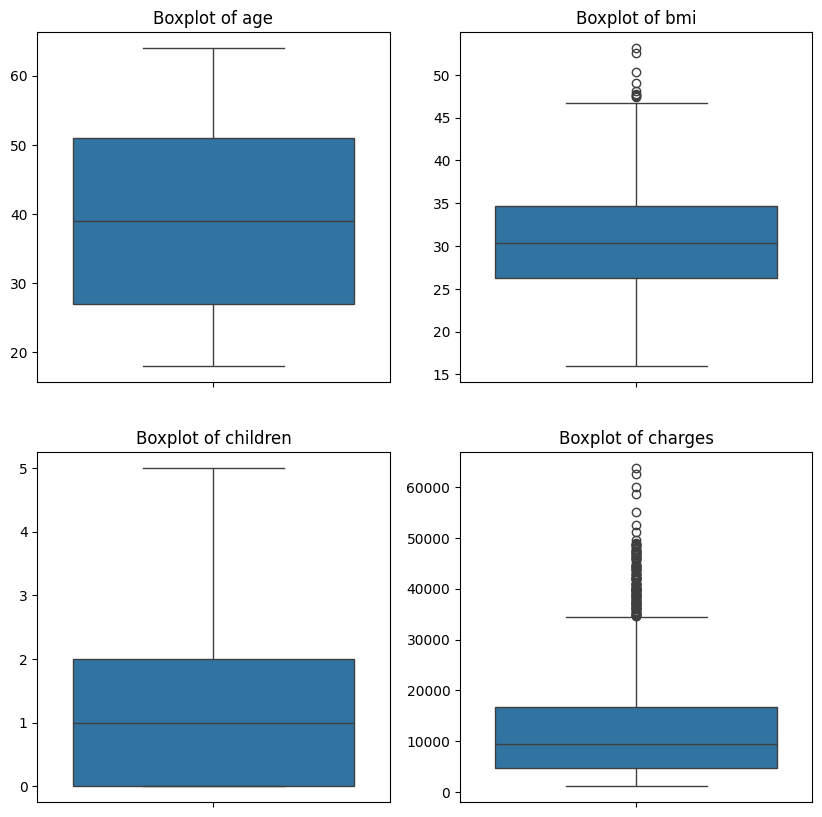

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, cols in enumerate(num_cols):
    sns.boxplot(y=raw_df[cols], ax=axes[i])
    axes[i].set_title(f"Boxplot of {cols}")
    axes[i].set_ylabel("")

### Log Transformation

After performing the log transformation to the charges feature, we now see how it is more bell-shaped and therefore suitable for later modeling.

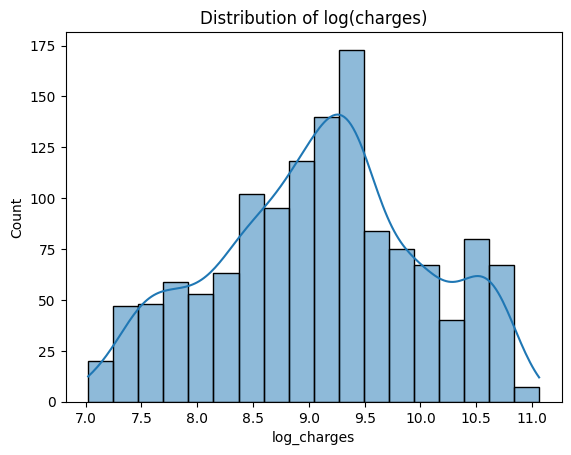

In [ ]:
health_df = raw_df.copy()

health_df["log_charges"] = np.log(health_df["charges"])
health_df.drop(columns=["charges"], inplace=True)

sns.histplot(health_df["log_charges"], kde=True)
plt.title("Distribution of log(charges)")
plt.show()

In [ ]:
health_df.head()

,age,sex,bmi,children,smoker,region,log_charges
0,19,female,27.900,0,yes,southwest,9.734176
1,18,male,33.770,1,no,southeast,7.453302
2,28,male,33.000,3,no,southeast,8.400538
3,33,male,22.705,0,no,northwest,9.998092
4,32,male,28.880,0,no,northwest,8.260197


## Feature Selection / Engineering

### Multicollinearity

Given the low multicollinearity between all our numeric features, there is no need to remove any feature from the list.

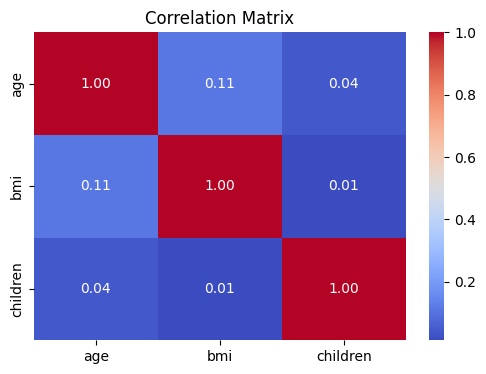

In [ ]:
num_cols.remove("charges")

plt.figure(figsize=(6,4)) # Set figure size

sns.heatmap(
    health_df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Train / Test Split

In [ ]:
RANDOM_STATE = 42

x = health_df.drop(columns=["log_charges"])
y = health_df["log_charges"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE
)

display(x_train.shape)
display(x_test.shape)

(1070, 6)

(268, 6)

## Model Fitting

We first start by creating the preprocess that holds instructions for how to transform the data for later fitting. For numeric columns, we will standardize the values as this is best practice when working with linear regression. For the categorical columns, we will be hot encoding them and dropping the first column of each.

In [ ]:
# Set up process for numeric and categorical columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), obj_cols)
    ],
    remainder="drop"
)

After this, we initialize a pipeline for the linear regression which will begin by calling the preprocess object as to know which transformation to perform based on the data type of the feature and then fit with an LR model and predict.

In [ ]:
# Pipeline creation

linereg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

# Fit with training data

linereg.fit(x_train, y_train)

# Predictions based on trained model

y_pred = linereg.predict(x_test)

## Coefficient Interpretation

As expected, smoking status is the strongest predictor in the model. The large positive coefficient indicates that, holding all other variables constant, smokers have substantially higher expected medical charges. Given that the model predicts log-transformed costs, this effect corresponds to a large multiplicative increase in expected expenses, consistent with the increased health risks associated with smoking.

Age is the second most influential predictor. Since numeric variables were standardized, the coefficient reflects the impact of a one standard deviation increase in age. The positive relationship aligns with expectations, as healthcare utilization and medical risks generally increase with age.

BMI and number of children also exhibit positive associations with medical costs, though their magnitudes are notably smaller compared to smoking and age. This suggests that while these factors contribute to increased healthcare expenses, their influence is secondary relative to smoking behavior.

The coefficient for male gender is slightly negative, indicating marginally lower predicted costs relative to the baseline category. However, given its small magnitude compared to other predictors, gender appears to have limited influence in this model.

Overall, the coefficient magnitudes reinforce domain knowledge: personal health risk factors drive medical expenditures more strongly than demographic or regional characteristics.

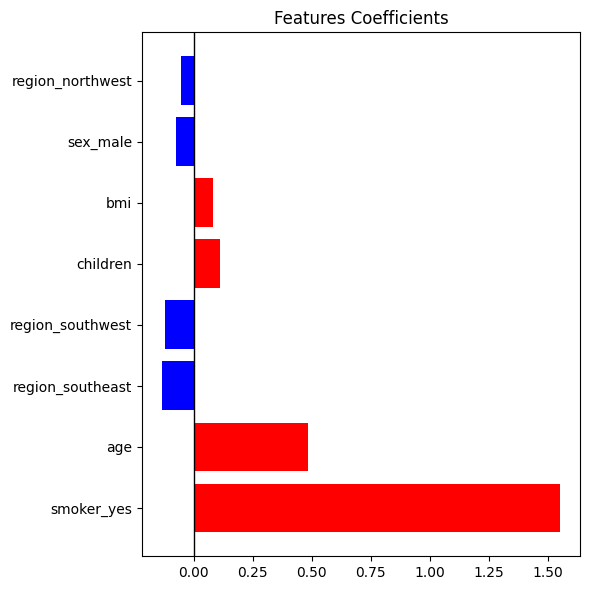

In [ ]:
# Get feature names from preprocessing step

feature_names = linereg.named_steps["preprocess"].get_feature_names_out()

# Get model coefficients

coefficients = linereg.named_steps["model"].coef_

# Create feature coefficients dataframe

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Remove num_ and cat_ from feature names

coef_df["Feature"] = coef_df["Feature"].str.replace("num__", "")
coef_df["Feature"] = coef_df["Feature"].str.replace("cat__", "")

# Sort by magnitude

coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

# Plot coefficients

colors = ["red" if x > 0 else "blue" for x in coef_df["Coefficient"]] # Red for coefficients the increase costs and blue for those that decrease costs

plt.figure(figsize=(6,6))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Features Coefficients")

plt.tight_layout()
plt.show()

## Model Evalutation

### Accuracy Metrics

Now, we generate the accuracy metrics. It is important to note that these are log units given the transformation done to the target variable in the previous steps. This must be reversed when wanting to see the actual value predictions.

Bsed on the R^2, the model is explaining ~80% of the variance of the predictions from the model against the test set. This is a good metric score for a dataset such as this one. Not only that, but having the Adj. R^2 almost the same as the R^2 is also a good sign given the Adj. R2 penalizes more based on the number of predictors being used. Given that the model is not using a lot of predictors (only 8 after hot encoding), we would expect both metrics to be close, otherwise we could assume there is some overfitness of the model. Since this is not the case, this suggests that the inclusion of our predictors does not inflate performance and that the model generalizes well to unseen data.

The MAE and RMSE are initially computed in log units due to the log transformation applied to the target variable. After exponentiating these values, we obtain multiplicative error factors of 1.31 (MAE) and 1.52 (RMSE). This means that, on average, predictions typically deviate by 31% from the true medical charges in relative terms, while larger errors can deviate by roughly 52%. The difference between RMSE and MAE indicates the presence of some larger prediction errors, which is expected in healthcare expenditure modeling due to extreme cases. Overall, these error magnitudes are consistent with strong performance for a linear regression model applied to skewed cost data. In dollar terms, the model\'s predictions deviate from actual charges by approximately \$3,900 on average (MAE), while larger deviations, penalized more heavily by RMSE, can reach approximately $7,800.

In [ ]:
# Get number of observations and predictors for adj. r2 calculation

x_train_transf = linereg.named_steps["preprocess"].transform(x_train)

n = len(y_test)
p = x_train_transf.shape[1]

# Calculate test metrics

r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
mae = np.exp(mean_absolute_error(y_test, y_pred))
rmse = np.exp(np.sqrt(mean_squared_error(y_test, y_pred)))

print(f"R^2:              {r2:.3f}")
print(f"Adj. R^2:         {adj_r2:.3f}")
print(f"MAE (no log):     {mae:.3f}")
print(f"RMSE (no log):    {rmse:.3f}")

# Convert target test and predictions to dollars

y_test_dollars = np.exp(y_test)
y_pred_dollars = np.exp(y_pred)

# Calculate MAE and RMSE for dollar values

mae_dollars = mean_absolute_error(y_test_dollars, y_pred_dollars)
rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))

print()
print(f"MAE ($):      ${mae_dollars:,.2f}")
print(f"RMSE ($):     ${rmse_dollars:,.2f}")

R^2:              0.805
Adj. R^2:         0.799
MAE (no log):     1.310
RMSE (no log):    1.520

MAE ($):      $3,888.77
RMSE ($):     $7,815.31


### Actual vs Predicted Scatterplot

The scatter plot shows predictions closely aligned along the 45-degree reference line, indicating strong agreement between predicted and actual charges. While dispersion increases slightly for higher-cost individuals, this is expected due to the inherent variability of medical expenses.

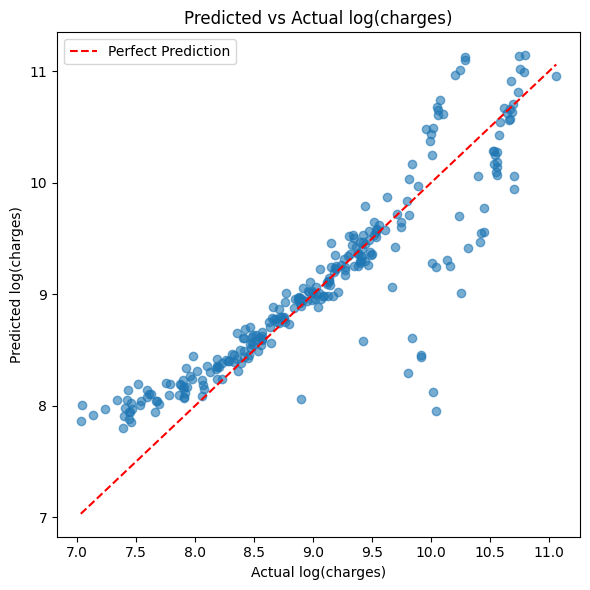

In [ ]:
plt.figure(figsize=(6,6))

# Scatter plot

plt.scatter(y_test, y_pred, alpha=0.6)

# 45-degree perfect prediction line

min_val = min(y_test.min(), y_pred.min())
max_val = min(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual log(charges)")
plt.ylabel("Predicted log(charges)")
plt.title("Predicted vs Actual log(charges)")
plt.legend()
plt.tight_layout()
plt.show()

### Residual Diagnosis

After visualizing the predicted vs actual scatter plot, we proceed to residual analysis.

The residuals vs predicted scatterplot shows errors centered around zero, indicating no strong systematic bias in the model’s predictions. A slight increase in dispersion can be observed at higher predicted cost levels, suggesting mild heteroscedasticity. This behavior is consistent with the nature of healthcare expenditure data, where variability increases for higher-cost individuals. However, the pattern is not strong enough to suggest model misspecification, particularly given the strong R^2 and Adj. R^2 values obtained earlier.

The residual distribution displays an approximately bell-shaped curve centered around zero, with a slight right tail. This indicates that while most predictions are close to the true values, there are some larger positive residuals corresponding to higher-cost cases. Such deviations are expected in medical cost modeling due to the heavy-tailed structure of the data. Overall, the residual diagnostics support the adequacy of a linear regression model applied to the log-transformed target variable.

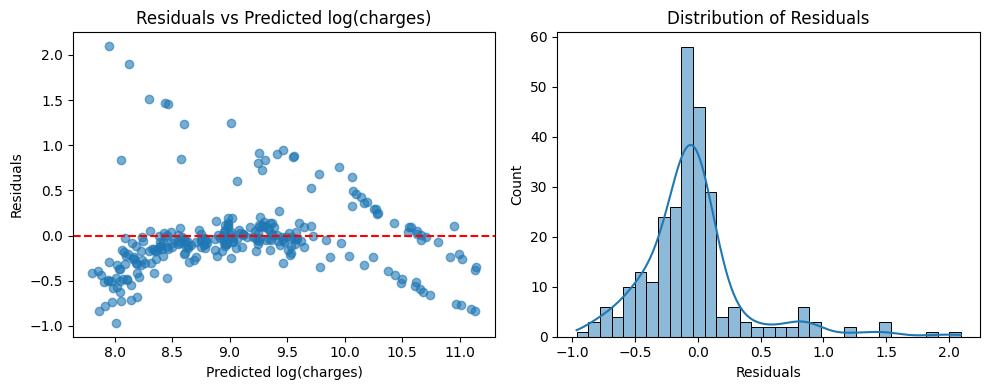

In [ ]:
# Calculation of residuals with log transformation

residuals = y_test - y_pred

# Setting up grids

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Scatterplot

axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted log(charges)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted log(charges)")

# Histogram

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_xlabel("Residuals")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

## Conclusion

The final model achieved an R^2 of approximately 0.80 on the test set, indicating that it explains around 80% of the variance in medical charges. The Adjusted R^2 being nearly identical suggests that the included predictors contribute meaningfully to the model without inflating performance. In dollar terms, the model’s predictions deviate by approximately $3,900 on average, which is acceptable given the inherent variability of healthcare expenditures.

Coefficient analysis revealed that smoking status is by far the most influential factor driving medical costs, followed by age. BMI and number of children also contribute positively, while gender and regional effects are comparatively minor. These findings align closely with domain knowledge, reinforcing the model’s interpretability and business relevance.

Residual diagnostics indicate that model assumptions are reasonably satisfied. While mild heteroscedasticity remains for higher-cost individuals, this is expected given the heavy-tailed structure of medical expenses and does not materially undermine model performance.

Overall, the linear regression model provides strong predictive power and clear interpretability. Future improvements could include interaction terms (e.g., smoking and BMI), non-linear models, or regularization techniques to further enhance predictive performance, particularly for extreme high-cost cases.